In [24]:
import pandas as pd
from collections import Counter
from itertools import combinations

In [25]:
from utils.plot_functions import plot_yearly_bar_chart

In [26]:
DATASET_PATH = "data/openalex_ai_healthcare_publications_1980_2026_filtered_2.csv"

In [27]:
publications_df = pd.read_csv(DATASET_PATH)

### **5. Country Collaboration Network**

This section analyzes international collaboration between countries based on institutional affiliations. A country collaboration network is created by representing countries as nodes and shared publications between country pairs as weighted edges. The section also examines the strongest collaboration pairs and the evolution of international publications over time.

#### **5.1 Building Nodes and Edges for Gephi**

This subsection constructs the node and edge tables required for Gephi. Each country is represented as a node, and an edge is created between two countries when they appear together in the affiliations of the same publication. Edge weights represent the number of shared publications between country pairs.

In [ ]:
def parse_countries(country_string):
    countries = [c.strip() for c in str(country_string).split(";") if c.strip()]

    return sorted(set(countries))

In [28]:
edge_counter = Counter()
country_paper_counter = Counter()

for _, row in publications_df.iterrows():
    countries = parse_countries(row["institution_countries"])

    if not countries:
        continue

    for country in countries:
        country_paper_counter[country] += 1

    if len(countries) >= 2:
        for c1, c2 in combinations(countries, 2):
            edge_counter[(c1, c2)] += 1

In [29]:
# Build nodes list
nodes_df = pd.DataFrame([
    {
        "Id": country,
        "Label": country,
        "paper_count": count
    }
    for country, count in country_paper_counter.items()
])

nodes_df = nodes_df.sort_values("paper_count", ascending=False)

nodes_df.head()

,Id,Label,paper_count
1,US,US,178560
4,CN,CN,170155
3,nan,nan,138321
11,IN,IN,84944
10,GB,GB,67663


In [30]:
# Build edges list
edges_df = pd.DataFrame([
    {
        "Source": source,
        "Target": target,
        "Weight": weight,
        "Type": "Undirected"
    }
    for (source, target), weight in edge_counter.items()
])

edges_df = edges_df.sort_values("Weight", ascending=False)

edges_df.head()

,Source,Target,Weight,Type
2,CN,US,17930,Undirected
16,GB,US,17865,Undirected
3,DE,US,11730,Undirected
5,CA,US,10350,Undirected
123,CN,GB,8703,Undirected


In [46]:
for top_n in [100, 150, 200, 300, 450, 600, len(edges_df)]:
    edges_gephi = (
        edges_df
        .sort_values("Weight", ascending=False)
        .head(top_n)
        .copy()
    )

    valid_nodes = set(edges_gephi["Source"]) | set(edges_gephi["Target"])
    nodes_gephi = nodes_df[nodes_df["Id"].isin(valid_nodes)].copy()

    nodes_gephi.to_csv(f"./data/network/country_nodes_gephi_top{top_n}.csv", index=False)
    edges_gephi.to_csv(f"./data/network/country_edges_gephi_top{top_n}.csv", index=False)

    print(
        f"Top {top_n}:",
        "nodes =", len(nodes_gephi),
        "edges =", len(edges_gephi),
        "min edge weight =", edges_gephi["Weight"].min()
    )

Top 100: nodes = 33 edges = 100 min edge weight = 1573
Top 150: nodes = 39 edges = 150 min edge weight = 1053
Top 200: nodes = 45 edges = 200 min edge weight = 814
Top 300: nodes = 55 edges = 300 min edge weight = 554
Top 450: nodes = 66 edges = 450 min edge weight = 335
Top 600: nodes = 79 edges = 600 min edge weight = 242
Top 10236: nodes = 219 edges = 10236 min edge weight = 1


#### **5.2 Top Country Collaboration Pairs**

This subsection identifies and visualizes the strongest country collaboration pairs based on edge weight. The ranked plot helps show which country pairs have the highest number of shared publications.

In [47]:
def plot_top_collaboration_pairs(
    edges_df,
    top_n=15,
    title="",
    xlabel="",
    ylabel="",
    save_file=None
):
    top_edges = (
        edges_df
        .sort_values("Weight", ascending=False)
        .head(top_n)
        .copy()
    )

    top_edges["pair"] = top_edges["Source"] + "–" + top_edges["Target"]

    top_edges = top_edges.iloc[::-1]

    fig, ax = plt.subplots(figsize=(14, 7))

    ax.barh(
        top_edges["pair"],
        top_edges["Weight"],
        height=0.72,
        color="#dbeafe",
        edgecolor="#2563eb",
        linewidth=1.2,
        zorder=2
    )

    ax.set_xlabel(xlabel, fontsize=15, labelpad=10)

    ax.set_ylabel(ylabel, fontsize=15, labelpad=10)
    ax.tick_params(axis="both", labelsize=12)

    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K" if x >= 1000 else f"{x:.0f}"))

    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.grid(axis="y", visible=False)
    ax.spines[["top", "right"]].set_visible(False)
    max_value = top_edges["Weight"].max()

    for i, value in enumerate(top_edges["Weight"]):
        ax.text(
            value + max_value * 0.01,
            i,
            f"{value:,.0f}",
            va="center",
            fontsize=11,
            color="#374151"
        )

    ax.set_xlim(0, max_value * 1.15)

    plt.tight_layout()

    if save_file:
        plt.savefig(save_file, dpi=300, bbox_inches="tight")

    plt.show()

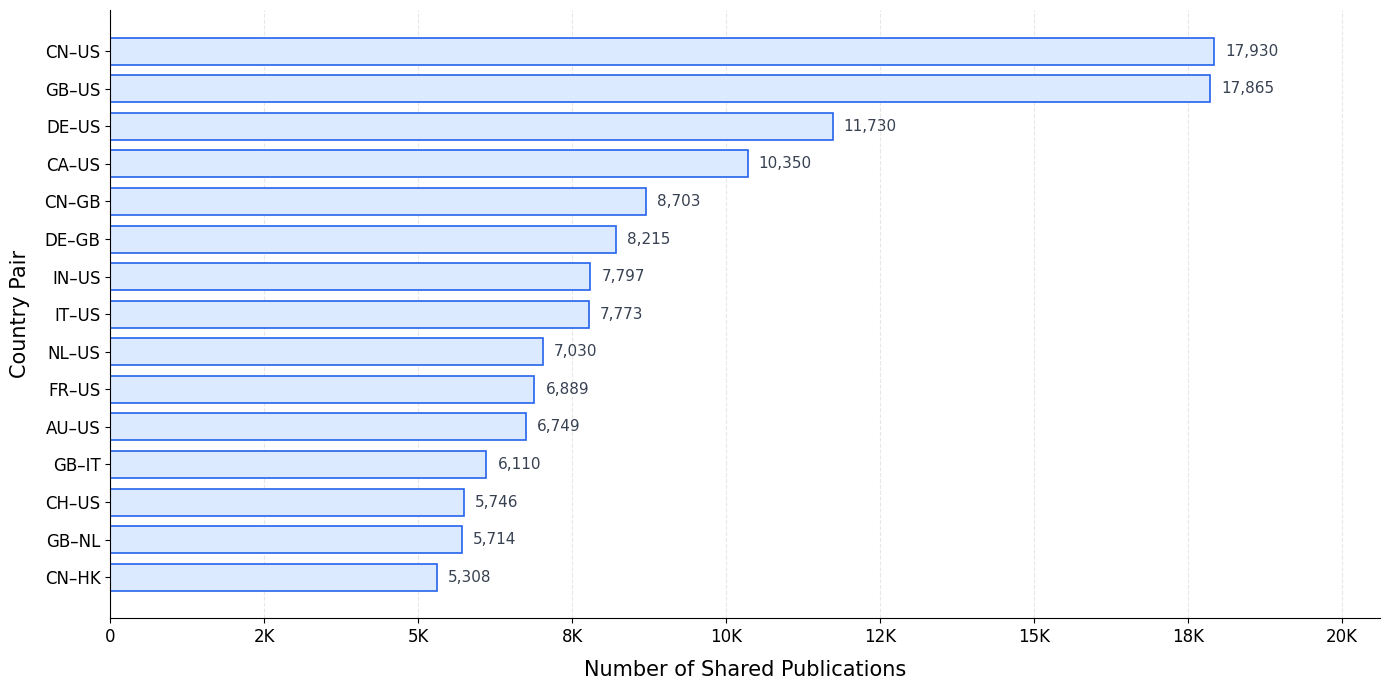

In [48]:
plot_top_collaboration_pairs(
    edges_df=edges_df,
    top_n=15,
    title="Top Country Collaboration Pairs in AI-in-Medicine Research",
    xlabel="Number of Shared Publications",
    ylabel="Country Pair",
    save_file="figures/top_country_collaboration_pairs.png"
)

#### **5.3 International Collaboration Over Time**

This subsection analyzes how the share of internationally collaborative publications changed over time. A publication is considered international if it contains institutional affiliations from at least two different countries.

In [49]:
publications_df["country_list"] = publications_df["institution_countries"].apply(parse_countries)

publications_df["n_countries"] = publications_df["country_list"].apply(len)

publications_df["international_collaboration"] = publications_df["n_countries"] >= 2

In [50]:
collaboration_by_year = (
    publications_df
    .groupby("publication_year")
    .agg(
        total_papers=("openalex_id", "count"),
        international_papers=("international_collaboration", "sum"),
        avg_countries_per_paper=("n_countries", "mean")
    )
    .reset_index()
)

collaboration_by_year["international_share"] = (
    collaboration_by_year["international_papers"] /
    collaboration_by_year["total_papers"]
)

collaboration_by_year.head(100)

,publication_year,total_papers,international_papers,avg_countries_per_paper,international_share
0,1980,53,2,1.037736,0.037736
1,1981,59,1,1.016949,0.016949
2,1982,67,5,1.119403,0.074627
3,1983,102,7,1.068627,0.068627
4,1984,128,2,1.015625,0.015625
5,1985,212,3,1.014151,0.014151
6,1986,263,9,1.034221,0.034221
7,1987,409,15,1.036675,0.036675
8,1988,545,18,1.053211,0.033028
9,1989,608,23,1.047697,0.037829


In [51]:
publication_year, international_share = collaboration_by_year["publication_year"], collaboration_by_year["international_share"]

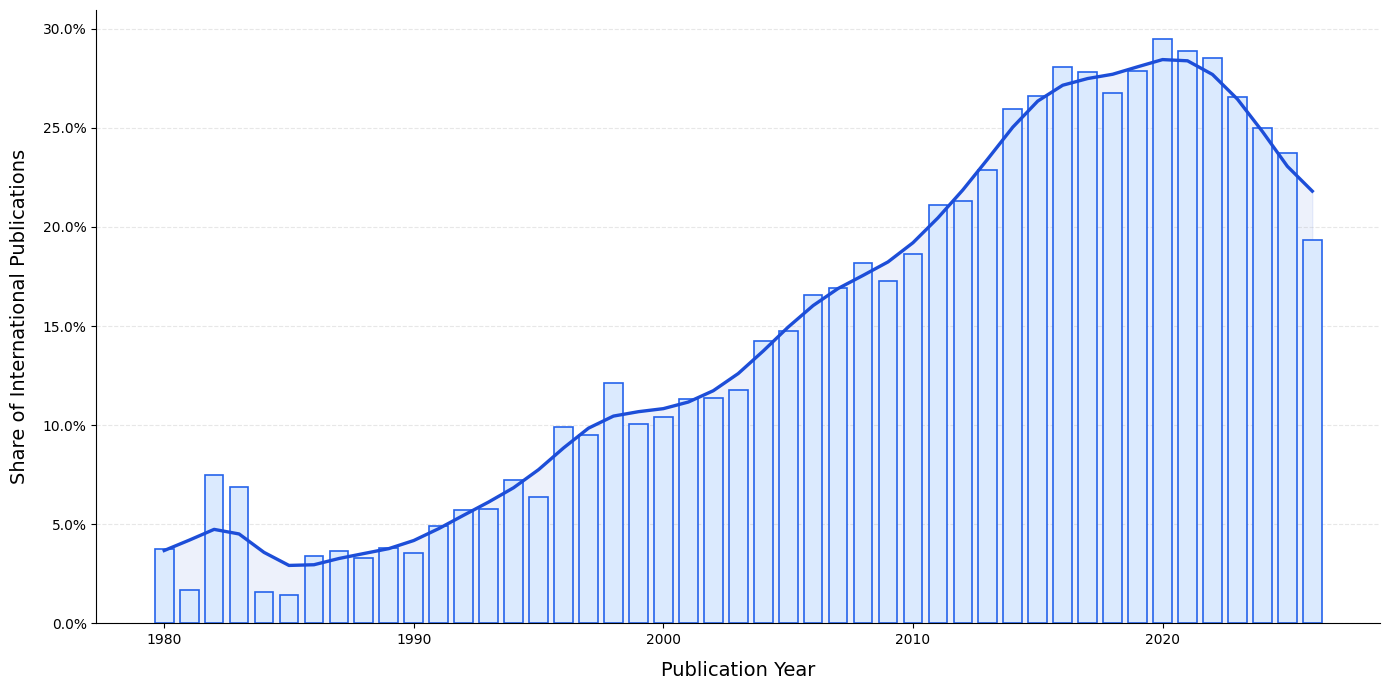

In [52]:
plot_yearly_bar_chart(
    publication_year, 
    international_share, 
    "",
    "Publication Year",
    "Share of International Publications",
    percentage=True,
    save_file = "figures/country_collaboration_growth_ai_medicine.png"
    )